# Orbital classify

Orbit classification based on the resonance angle behaviour.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import galport

Load coordinates, velocities and actions for the set of orbits

In [20]:
xv_act = np.load('data/xv_act_0.npy')

t = np.arange(0, 600.125, 0.125)
xv = xv_act[:,:,0:6]
act = xv_act[:,:,6:9]

theta_p = np.load('data/phi_p.npy')
Omega_p = np.load('data/omega_p.npy')

Find actions, angles and frequencies of the every orbit and Orbit classification at time $t=400$

In [26]:
%%time

OT = galport.OrbitTools(t=t, xv=xv, act=act)
data = OT.calculate_actions(secular=True)
otype_ILR = OT.classify_orbits(t_out=400, family='ILR', theta_p=theta_p)
otype_vILR = OT.classify_orbits(t_out=400, family='vILR', theta_p=theta_p)
otype_uha = OT.classify_orbits(t_out=400, family='uha', theta_p=theta_p)

CPU times: user 2.33 s, sys: 6.88 ms, total: 2.34 s
Wall time: 2.34 s


Equivalent code for classification (calling the ``OrbitClassifier`` module directly)

In [38]:
ang = OT.angles
# or
ang = data[:, :, 3:6] # if dJdt=False
# ang = OT.data[:, :, 6:9] # if dJdt=True

OC = galport.OrbitClassifier(t, angles=ang, theta_p=theta_p, time_resolution=5.)
# Not all angles are used in the classification; they are taken with a time step of `time_resolution`
result = OC(t_out=400, family='ILR', time_around_res=False, amplitude_res=False)
# or, you can also set the resonant angle yourself
OC = galport.OrbitClassifier(t, angles=2*(ang[:,:,2] - theta_p) - ang[:,:,0], time_resolution=5.)
result = OC(t_out=400, time_around_res=True, amplitude_res=False)

**List of types**

`0`: Not classify

`1`: Increasing angle

`2`: Decreasing angle

`3`: Resonance around $0$

`4`: Resonance around $\pi$

`5`: Passage through $0$ from $\Omega_{res} > 0$ to $\Omega_{res} < 0$

`6`: Passage through $\pi$ from $\Omega_{res} > 0$ to $\Omega_{res} < 0$

`7`: Passage through $0$ from $\Omega_{res} < 0$ to $\Omega_{res} > 0$

`8`: Passage through $\pi$ from $\Omega_{res} < 0$ to $\Omega_{res} > 0$

**Additional variables**

`time_around_res`: returns the resonance entry and exit times for resonant orbits

`amplitude_res`: returns the maximum libration amplitude of the resonant angle

Secular actions and frequencies

In [36]:
t0 = 400
n_t = int(t0)*8

JR_sec = data[:,n_t,9]
Jz_sec = data[:,n_t,10]
Lz_sec = data[:,n_t,11]

kappa_sec = data[:,n_t,12]
omegaz_sec = data[:,n_t,13]
Omega_sec = data[:,n_t,14] - Omega_p[n_t]

Plot different orbital types on the plane $2(\Omega - \Omega_p)/\kappa$ vs $\omega_z\kappa$

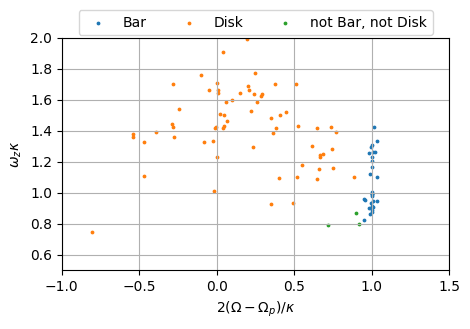

In [37]:
fig, ax = plt.subplots(figsize=(5,5))
ax.set_aspect('equal')

ax.grid(zorder=-1)

test_bar = (otype_ILR > 2)
test_notbarnotdisk = (otype_ILR <= 2) & (otype_uha == 1) & (otype_vILR == 2)
test_disk = ~test_bar & ~test_notbarnotdisk


ax.scatter(
    2*Omega_sec[test_bar]/kappa_sec[test_bar],
    omegaz_sec[test_bar]/kappa_sec[test_bar],
    s=3, label='Bar'
)

ax.scatter(
    2*Omega_sec[test_disk]/kappa_sec[test_disk],
    omegaz_sec[test_disk]/kappa_sec[test_disk],
    s=3, label='Disk'
)

ax.scatter(
    2*Omega_sec[test_notbarnotdisk]/kappa_sec[test_notbarnotdisk],
    omegaz_sec[test_notbarnotdisk]/kappa_sec[test_notbarnotdisk],
    s=3, label='not Bar, not Disk'
)


ax.set_xlabel('$2(\\Omega - \\Omega_p)/\\kappa$')
ax.set_ylabel('$\\omega_z\\kappa$')
ax.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, 1.15),
    ncols=3
)

ax.set_xlim(-1.0,1.5)
ax.set_ylim(0.5, 2)

plt.show()